This notebook produces Figures S3 and S4, which are synthetic data tests that illustrate how pixel brightness and coherence window size affect the resulting coherence magnitude estimates.
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [1]:
# import necessary packages 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
%matplotlib  widget

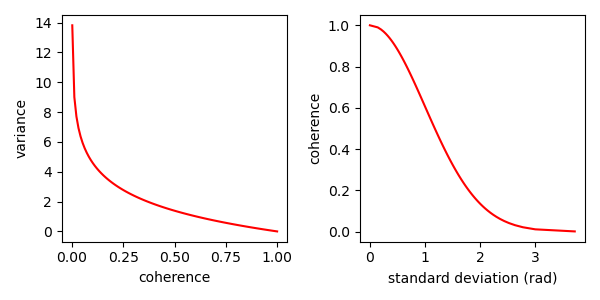

In [2]:
# theoretical relationship between coherence and variance 
# these plots are not in the paper but can help visualization of the relationship.
cohs = np.linspace(0.001,1,100)
vars = -2*np.log(cohs)

plt.figure(figsize=(6,3),tight_layout=True)
plt.subplot(1,2,1)
plt.plot(cohs,vars,'r-')
plt.ylabel('variance'); plt.xlabel('coherence')
plt.subplot(1,2,2)
plt.plot(np.sqrt(vars),cohs,'r-')
plt.xlabel('standard deviation (rad)'); plt.ylabel('coherence')
plt.show()

In [3]:
# calculate statistics on 100 pixels for 100000 iterations 
numPix = 100
numIters = 100000

In [4]:
# make complex vectors of length one, with phase behavior governed by the phase standard deviation (std) defined below.

# for a given coherence
coh = 0.5
# the std is estimated as follows:
std_theoretical = np.sqrt(-2*np.log(coh)) # sqrt because doing std not variance
print('For coh '+str(coh)+', std is ~'+str(std_theoretical))

# create a gaussian phase distribution 
phase_vals = np.random.normal(loc=0.0, scale=std_theoretical, size=(numIters,numPix))
# all length 1, with phase distribution defined above.
igram_vals = 1*np.exp(1j*phase_vals)
# this is the same as assuming slcA is all zero phases, then the igram becomes -slcB

For coh 0.5, std is ~1.1774100225154747


In [5]:
# calculating complex coherence magnitude requires that we have phase/amplitude values for the previous SLC
# so we have to make them here. (length 1)
slc_previous = 1*np.exp(1j*np.zeros((numIters,numPix)))

(100000, 100)


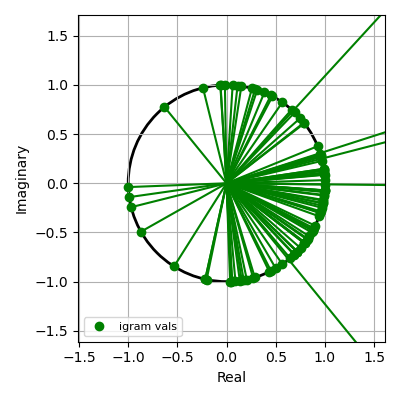

In [6]:
# what about if only a few pixels' magnitudes are huge relative to the others?
fracbig = 0.05
big = int(numPix*fracbig)
igram_few_big_mag = igram_vals.copy()
print(np.shape(igram_few_big_mag))
igram_few_big_mag[:,0:big] = 100*np.exp(1j*phase_vals[:,0:big])
slc_previous_big_mag = np.copy(slc_previous) 
slc_previous_big_mag[:,0:big]=100*slc_previous_big_mag[:,0:big]
# which iteration of the numIters? 
i = 3
real_vals2 = np.real(igram_few_big_mag[i])
imag_vals2 = np.imag(igram_few_big_mag[i])

# plot them to see them visually on the imaginary circle.
plt.figure(figsize=(4,4),tight_layout=True)
plt.plot(real_vals2,imag_vals2,'go',label='igram vals')
for i in range(numPix):
    plt.plot([0,real_vals2[i]],[0,imag_vals2[i]],'g-')
    #plt.annotate(labels[i],(real_vals[i],imag_vals[i]))
plt.axis('equal'); plt.xlabel('Real'); plt.ylabel('Imaginary')
unit_circ = plt.Circle((0,0),1,linewidth=2,edgecolor='k',facecolor='none')
plt.gca().add_patch(unit_circ)
plt.xlim(-1.5,1.6); plt.ylim(-1.5,1.6)
plt.grid(); plt.legend(fontsize=8,loc='lower left')
plt.show()

In [7]:
# create an array which will be the set of numbers of pixels we will calculate coherence over 
# will loop over these for Figure S3
Ns_to_test = np.arange(0,100,5)
Ns_to_test[0] = 1 # because we can't calculate coherence over zero pixels.
# print('Ns to test:')
# print((Ns_to_test))
cohs_with_diff_Ns = np.ndarray((len(Ns_to_test),),dtype='float')

for i in range(len(Ns_to_test)):
    # how many pixels to calculate coherence over for this example? 
    n = int(Ns_to_test[i])
    # calculate coherences of that many pixels 
    cohs = np.mean(igram_few_big_mag[:,0:n]/np.abs(igram_few_big_mag[:,0:n]),axis=(1))
    cohs_with_diff_Ns[i] = np.mean(np.abs(cohs))
    # print(np.mean(np.abs(cohs)))

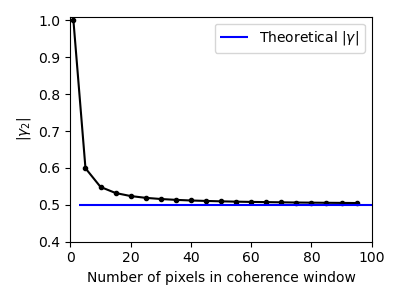

In [8]:
# This is Figure S3.
plt.figure(figsize=(4,3),tight_layout=True)
plt.plot(Ns_to_test,cohs_with_diff_Ns,'k.-')
plt.xlabel('Number of pixels in coherence window')
plt.ylabel('$|\\gamma_{2}|$')
plt.hlines(0.5,3,100,'b',label='Theoretical $|\gamma|$')
plt.legend()
plt.xlim(0,100); plt.ylim(0.4,1.01)
plt.show()
# plt.savefig('synthetic_test_window_sizes.png',transparent=True,bbox_inches='tight',dpi=500)

In [9]:
# now loop over input stds for a given fraction of large amplitude pixels 
stds = np.arange(0,2.6,0.1) # this is 50 values 
numStds = len(stds)

In [10]:
# make a function that outputs calculated cohs (methods 1+2) with a given input std 
# and a given fraction of pixels with MUCH larger amplitude/magnitude/backscatter intensity of a given value
def calc_cohs_methods_12(phase_std,frac_large_mags,large_mag):
    
    # first calculate the "theoretical" coh 
    phase_var = phase_std**2
    coh_theor = np.exp(-(phase_var)/2)
    
    # make amplitude values with desired distribution (frac_large_mags% of pixels have large_mag amplitude)
    # remains the same for all iterations 
    mag_vals_temp = np.ones((numPix,))
    mag_vals_temp[0:int(frac_large_mags*numPix)] = large_mag

    # initialize array to hold all iterations of coherence method1 and method2
    cohs_m1 = np.ndarray((numIters,),dtype='float')
    cohs_m2 = np.ndarray((numIters,),dtype='float')
    
    # loop over iterations 
    for i in range(numIters): #(numIters)
        # make phase values with the desired distribution 
        phase_vals_temp = np.random.normal(loc=0.0, scale=phase_std, size=(numPix,))
        
        # make the igram itself, with phase distribution and amp distribution defined above.
        slc_2 = mag_vals_temp*np.exp(1j*phase_vals_temp)
        
        # now calculate complex coherence magnitude (method 1) 
        slc_1 = mag_vals_temp * np.exp(1j*np.zeros((numPix)))
        m1_numer = np.mean(slc_1*np.conj(slc_2)) 
        m1_denom = np.sqrt(np.mean(slc_1*np.conj(slc_1)) * np.mean(slc_2*np.conj(slc_2)))
        coh_m1_temp = np.abs(m1_numer / m1_denom)
        cohs_m1[i] = coh_m1_temp

        # now calculate unit vector coherence magnitude (method 2)
        coh_m2_temp = np.abs(np.mean(slc_2/np.abs(slc_2)))
        cohs_m2[i] = coh_m2_temp
    
    return(coh_theor,cohs_m1,cohs_m2)

In [ ]:
# now loop over input stds for a different fractions of large amplitude pixels 
# takes a while to run, 5-10 minutes

fractions_big = [0.01,0.02,0.03,0.05,0.1,0.25,0.5]
num_fracs = len(fractions_big)
big_mag  = 100

m1_fracs_cohs    = np.ndarray((numStds,num_fracs),dtype='float')
m2_fracs_cohs    = np.ndarray((numStds,num_fracs),dtype='float')

for i in range(len(stds)):
    for j in range(num_fracs):
        theoretical_coh_throwaway, m1_cohs_temp, m2_cohs_temp = calc_cohs_methods_12(stds[i],fractions_big[j],big_mag)
        m1_fracs_cohs[i,j] = np.mean(m1_cohs_temp)
        m2_fracs_cohs[i,j] = np.mean(m2_cohs_temp)

In [12]:
theoretical_cohs = np.ndarray((numStds,),dtype='float')
frac_big = 0.05
big_mag  = 100

for i in range(len(stds)):
    theoretical_cohs[i], m1_cohs_temp, m2_cohs_temp = calc_cohs_methods_12(stds[i],frac_big,big_mag)

In [ ]:
#cols = ['cornflowerblue','purple','green','darkgoldenrod','darkmagenta','saddlebrown','olive']
cols = [
    "#8B0000",  # Dark Red
    "#C95A0A",  # Saddle Brown (dark orange/brown)
    "#B8860B",  # Dark Goldenrod (dark yellow)
    "#006400",  # Dark Green
    "#483D8B",  # Dark Slate Blue (dark blue)
    "#4B0082",  # Indigo
    "#800080"   # Purple (dark violet)
]
plt.figure(figsize=(9,4),tight_layout=True)
for i in range(num_fracs):
    # plt.plot(stds,m1_fracs_cohs[:,i],color=cols[i],linestyle='-',linewidth=2,label='$|\\gamma_{1}|$, '+str(fractions_big[i]*100)+'% large mag.')
    plt.plot(stds,m1_fracs_cohs[:,i],color=cols[i],linestyle='-',linewidth=2,label='$|\\gamma_{1}|$, '+f'{int(fractions_big[i]*100)}'+'% bright pixels')
# Unit vector coherence always the same no matter what 
plt.plot(stds,m2_fracs_cohs[:,0],'k:',linewidth=3,label='$|\\gamma_{2}|$')
plt.plot(stds,theoretical_cohs,'k-',label='Theoretical coherence')
plt.xlabel('Phase Standard Deviation, $\\sigma$ (rad)')
plt.xlim(0,2.5)
plt.ylabel('Coherence Magnitude')
plt.legend(bbox_to_anchor=(1.02, 0.83))
plt.legend(loc='lower left')
plt.show()
# plt.savefig('synthetic_test_bright_dark.png',transparent=True,bbox_inches='tight',dpi=500)